# OPTIMASI KONFIGURASI MATRIKS WORKER DAN PARTISI DATA TERDISTRIBUSI BERBASIS HDFS UNTUK KLASIFIKASI KANKER KULIT MENGGUNAKAN APACHE SPARK

Notebook ini dirancang khusus untuk penelitian skripsi dengan arsitektur **Hybrid Komputasi Terdistribusi Big Data & Deep Learning**:
1. **Lapisan Penyimpanan:** Hadoop Distributed File System (HDFS) di `hdfs://localhost:9000`.
2. **Lapisan Manajer Klaster:** Apache Spark Standalone Cluster (`spark://localhost:7077`) tanpa dependensi YARN.
3. **Matriks Eksperimen ($2^2$ Full Factorial Design):**
   - **W2-P2:** 2 Worker, 2 Partisi (Baseline Rendah)
   - **W2-P8:** 2 Worker, 8 Partisi (Fine-grained Data Partitioning)
   - **W8-P2:** 8 Worker, 2 Partisi (Uji Worker Starvation / Resource Bottleneck)
   - **W8-P8:** 8 Worker, 8 Partisi (High Concurrency / Scalability)
4. **Validitas Medis (Zero Patient Leakage):** Membaca subset resmi `dataset_irisan_3kelas_train.csv`, `val.csv`, dan `test.csv` berbasis `StratifiedGroupKFold` pada `lesion_id`.
5. **Pemodelan AI:** ResNet-50 ImageNet + Triplet Attention Module (WACV 2021) pada `conv4_block6_out`.


## Fase 0 - Dependency Python & Library Eksternal
Sel ini memasang pustaka Python yang dibutuhkan sebelum modul lain diimpor. Dipasang di awal agar tidak terjadi *ModuleNotFoundError* di tengah jalan. Versi PySpark diselaraskan dengan Spark 3.5.5.


In [3]:
%pip install -q findspark pyspark==3.5.5 psutil seaborn pyarrow scikit-learn
print("Dependency Python selesai dipasang. Lingkungan siap.")


Note: you may need to restart the kernel to use updated packages.
Dependency Python selesai dipasang. Lingkungan siap.


## Fase 1 - Setup Lingkungan, Parameter Matriks, dan Direktori Kerja
Mendefinisikan parameter penelitian, matriks eksperimen, dan direktori kerja.
Pilih `SCENARIO_INDEX` (0 sampai 3) untuk menjalankan salah satu kombinasi matriks.


In [62]:
from pathlib import Path
import os
import sys
import subprocess
import time
import json
import csv
import shutil
import gc
import io
import random
import threading
from datetime import datetime

ENV_NAME = 'kaggle' if Path('/kaggle/working').exists() else 'colab'
INSTALL_DIR = Path('/kaggle/temp/spark_runtime') if ENV_NAME == 'kaggle' else Path('/content')
PROJECT_DIR = Path('/kaggle/working/riset_kanker_kulit') if ENV_NAME == 'kaggle' else INSTALL_DIR / 'riset_kanker_kulit'
CACHE_DIR = INSTALL_DIR / 'cache'
SCRIPT_DIR = PROJECT_DIR / 'scripts'
DATA_DIR = Path('/kaggle/temp/hadoop_data') if ENV_NAME == 'kaggle' else INSTALL_DIR / 'hadoop_data'

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SCRIPT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# TABEL MATRIKS EKSPERIMEN (2x2 FACTORIAL DESIGN)
# =============================================================================
SCENARIO_MATRIX = [
    (2, 2),  # Index 0: W2-P2 (Baseline)
    (2, 8),  # Index 1: W2-P8 (Worker Sedikit, Partisi Banyak)
    (8, 2),  # Index 2: W8-P2 (Worker Banyak, Partisi Sedikit -> Worker Starvation)
    (8, 8),  # Index 3: W8-P8 (Worker Banyak, Partisi Banyak -> High Concurrency)
]

# GANTI INDEX INI (0, 1, 2, atau 3) UNTUK MENJALANKAN SKENARIO TERTENTU
SCENARIO_INDEX = 3

if not 0 <= SCENARIO_INDEX < len(SCENARIO_MATRIX):
    raise ValueError('SCENARIO_INDEX harus berada pada rentang 0 sampai 3.')

NUM_WORKERS, NUM_PARTITIONS = SCENARIO_MATRIX[SCENARIO_INDEX]
SCENARIO_CODE = f'W{NUM_WORKERS}-P{NUM_PARTITIONS}'
EPOCHS = 15
BATCH_SIZE = 32
IMG_SIZE = 224
SHARD_SIZE = 64
CLASS_NAMES = ['nevus', 'melanoma', 'seborrheic_keratosis']
LABEL_MAP = {'NV': 'nevus', 'MEL': 'melanoma', 'BKL': 'seborrheic_keratosis'}
NUM_CLASSES = len(CLASS_NAMES)

HADOOP_VERSION = '3.3.6'
SPARK_VERSION = '3.5.5'
SPARK_PROFILE = 'hadoop3'
HADOOP_HOME = INSTALL_DIR / 'hadoop'
SPARK_HOME = INSTALL_DIR / 'spark'
HADOOP_CONF_DIR = HADOOP_HOME / 'etc' / 'hadoop'
HDFS_URI = 'hdfs://localhost:9000'
HDFS_DATA_DIR = '/user/skincancer/irisan'
HDFS_SHARD_DIR = '/user/skincancer/irisan_shards'
RESULTS_PATH = PROJECT_DIR / 'results_matriks_standalone.csv'

def run(command, check=True, capture=False):
    return subprocess.run(command, check=check, text=True, capture_output=capture)

print(f'Environment: {ENV_NAME} | Skenario Aktif: {SCENARIO_CODE} (Workers={NUM_WORKERS}, Partitions={NUM_PARTITIONS})')
print(f'Project Dir: {PROJECT_DIR}')


Environment: kaggle | Skenario Aktif: W8-P8 (Workers=8, Partitions=8)
Project Dir: /kaggle/working/riset_kanker_kulit


## Fase 1.1 - Pemasangan Komponen Sistem (Java 11, SSH, Hadoop 3.3.6, Spark 3.5.5)
Skrip ini memasang OpenJDK 11, server SSH bebas password (kebutuhan script internal Hadoop), serta mengunduh dan mengekstrak binari Hadoop 3.3.6 dan Spark 3.5.5 ke direktori runtime `/kaggle/temp/spark_runtime`.


In [5]:
SETUP = f'''#!/bin/bash
set -e
INSTALL_DIR="{INSTALL_DIR}"
CACHE_DIR="{CACHE_DIR}"
HADOOP_HOME="{HADOOP_HOME}"
SPARK_HOME="{SPARK_HOME}"
mkdir -p "$INSTALL_DIR" "$CACHE_DIR"

# 1. Pemasangan Java 11 & OpenSSH Server
if ! (java -version 2>&1 | grep -q 'version "11.' && command -v ssh >/dev/null 2>&1 && command -v sshd >/dev/null 2>&1); then
  echo "Memasang OpenJDK 11 dan OpenSSH Server..."
  timeout 180 apt-get update -qq
  DEBIAN_FRONTEND=noninteractive timeout 300 apt-get install -y -qq openjdk-11-jdk-headless openssh-client openssh-server
else
  echo "Java 11 dan SSH server sudah tersedia; apt-get dilewati."
fi

# 2. Konfigurasi Passwordless SSH untuk Daemon Hadoop
mkdir -p /var/run/sshd /root/.ssh
ssh-keygen -A >/dev/null 2>&1 || true
if [ ! -f /root/.ssh/id_rsa ]; then
  ssh-keygen -t rsa -N '' -f /root/.ssh/id_rsa -q
fi
touch /root/.ssh/authorized_keys
cat /root/.ssh/id_rsa.pub >> /root/.ssh/authorized_keys
chmod 700 /root/.ssh
chmod 600 /root/.ssh/authorized_keys
cat > /root/.ssh/config <<'SSHCONFIG'
Host localhost 127.0.0.1
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    LogLevel ERROR
SSHCONFIG
chmod 600 /root/.ssh/config
if ! pgrep -x sshd >/dev/null 2>&1; then
  /usr/sbin/sshd
fi

# 3. Fungsi Unduh Arsip dengan Cache Terproteksi
fetch() {{
  name="$1"; url="$2"; target="$INSTALL_DIR/$name"; cache="$CACHE_DIR/$name"
  if [ -f "$target" ] && tar -tzf "$target" >/dev/null 2>&1; then
    echo "Arsip valid sudah tersedia: $name"
    return 0
  fi
  if [ -f "$target" ]; then
    echo "Arsip lokal rusak, menghapus: $target"
    rm -f "$target"
  fi
  if [ -f "$cache" ] && tar -tzf "$cache" >/dev/null 2>&1; then
    echo "Menggunakan cache arsip valid: $name"
    cp "$cache" "$target"
    return 0
  fi
  if [ -f "$cache" ]; then
    echo "Cache arsip rusak, menghapus: $cache"
    rm -f "$cache"
  fi
  echo "Mengunduh ulang arsip: $name"
  partial="$target.part"
  rm -f "$partial"
  wget -q --tries=5 --timeout=60 "$url" -O "$partial"
  tar -tzf "$partial" >/dev/null 2>&1
  mv "$partial" "$target"
  cp "$target" "$cache"
}}

# 4. Ekstrak Hadoop & Spark
if [ ! -x "$HADOOP_HOME/bin/hdfs" ]; then
  rm -rf "$HADOOP_HOME"
  fetch hadoop-{HADOOP_VERSION}.tar.gz https://archive.apache.org/dist/hadoop/common/hadoop-{HADOOP_VERSION}/hadoop-{HADOOP_VERSION}.tar.gz
  tar -xzf "$INSTALL_DIR/hadoop-{HADOOP_VERSION}.tar.gz" -C "$INSTALL_DIR"
  mv "$INSTALL_DIR/hadoop-{HADOOP_VERSION}" "$HADOOP_HOME"
fi
if [ ! -x "$SPARK_HOME/bin/spark-submit" ]; then
  rm -rf "$SPARK_HOME"
  fetch spark-{SPARK_VERSION}-bin-{SPARK_PROFILE}.tgz https://archive.apache.org/dist/spark/spark-{SPARK_VERSION}/spark-{SPARK_VERSION}-bin-{SPARK_PROFILE}.tgz
  tar -xzf "$INSTALL_DIR/spark-{SPARK_VERSION}-bin-{SPARK_PROFILE}.tgz" -C "$INSTALL_DIR"
  mv "$INSTALL_DIR/spark-{SPARK_VERSION}-bin-{SPARK_PROFILE}" "$SPARK_HOME"
fi
rm -f "$INSTALL_DIR/hadoop-{HADOOP_VERSION}.tar.gz" "$INSTALL_DIR/spark-{SPARK_VERSION}-bin-{SPARK_PROFILE}.tgz"
rm -f "$CACHE_DIR/hadoop-{HADOOP_VERSION}.tar.gz" "$CACHE_DIR/spark-{SPARK_VERSION}-bin-{SPARK_PROFILE}.tgz"
mkdir -p /var/run/sshd
'''
setup_path = SCRIPT_DIR / 'setup_env.sh'
setup_path.write_text(SETUP)
setup_path.chmod(0o755)
run(['bash', str(setup_path)])
print('Setup sistem dasar selesai.')


Memasang OpenJDK 11 dan OpenSSH Server...


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Preconfiguring packages ...
(Reading database ... 125186 files and directories currently installed.)
Preparing to unpack .../0-openssh-client_1%3a8.9p1-3ubuntu0.17_amd64.deb ...
Unpacking openssh-client (1:8.9p1-3ubuntu0.17) over (1:8.9p1-3ubuntu0.15) ...
Selecting previously unselected package openssh-sftp-server.
Preparing to unpack .../1-openssh-sftp-server_1%3a8.9p1-3ubuntu0.17_amd64.deb ...
Unpacking openssh-sftp-server (1:8.9p1-3ubuntu0.17) ...
Selecting previously unselected package openssh-server.
Preparing to unpack .../2-openssh-server_1%3a8.9p1-3ubuntu0.17_amd64.deb ...
Unpacking openssh-server (1:8.9p1-3ubuntu0.17) ...
Selecting previously unselected package ncurses-term.
Preparing to unpack .../3-ncurses-term_6.3-2ubuntu0.3_all.deb ...
Unpacking ncurses-term (6.3-2ubuntu0.3) ...
Selecting previously unselected package openjdk-11-jre-headless:amd64.
Preparing to unpack .../4-openjdk-11-jre-headless_11.0.32.1+1-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:a

## Fase 1.2 - Konfigurasi Environment Variable Sistem
Menentukan lokasi `JAVA_HOME`, `HADOOP_HOME`, `SPARK_HOME`, dan memperbarui `PATH`. Sel ini dijalankan setelah Java 11 berhasil dipasang oleh skrip setup.


In [6]:
def resolve_java_home():
    candidates = [
        Path('/usr/lib/jvm/java-11-openjdk-amd64'),
        Path('/usr/lib/jvm/java-11-openjdk'),
        Path('/usr/lib/jvm/default-java')
    ]
    for candidate in candidates:
        if candidate.exists() and (candidate / 'bin' / 'java').exists():
            return str(candidate)
    java_bin = shutil.which('java')
    if java_bin:
        resolved = Path(run(['readlink', '-f', java_bin], capture=True).stdout.strip())
        return str(resolved.parent.parent)
    raise FileNotFoundError('Java tidak ditemukan. Pastikan Fase 1.1 telah dijalankan.')

os.environ['JAVA_HOME'] = resolve_java_home()
os.environ['HADOOP_HOME'] = str(HADOOP_HOME)
os.environ['SPARK_HOME'] = str(SPARK_HOME)
os.environ['HADOOP_CONF_DIR'] = str(HADOOP_CONF_DIR)
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
os.environ['PATH'] = ':'.join([
    str(Path(os.environ['JAVA_HOME']) / 'bin'),
    str(HADOOP_HOME / 'bin'),
    str(HADOOP_HOME / 'sbin'),
    str(SPARK_HOME / 'bin'),
    str(SPARK_HOME / 'sbin'),
    os.environ.get('PATH', '')
])

print('JAVA_HOME   =', os.environ['JAVA_HOME'])
print('HADOOP_HOME =', HADOOP_HOME)
print('SPARK_HOME  =', SPARK_HOME)


JAVA_HOME   = /usr/lib/jvm/java-11-openjdk-amd64
HADOOP_HOME = /kaggle/temp/spark_runtime/hadoop
SPARK_HOME  = /kaggle/temp/spark_runtime/spark


## Fase 1.3 - Pembersihan Cache Installer Sementara
Menghapus file tarball sisa pengunduhan agar tidak membebani kuota disk `/kaggle/working`.


In [7]:
for p in [
    Path('/kaggle/working/hadoop-3.3.6.tar.gz'),
    Path('/kaggle/working/spark-3.5.5-bin-hadoop3.tgz'),
    CACHE_DIR / 'hadoop-3.3.6.tar.gz',
    CACHE_DIR / 'spark-3.5.5-bin-hadoop3.tgz'
]:
    if p.exists():
        p.unlink()
        print('Dihapus:', p)
print('Cleanup storage selesai.')


Cleanup storage selesai.


## Fase 2 - Konfigurasi dan Layanan HDFS
HDFS bertindak sebagai lapisan penyimpanan terdistribusi untuk citra medis pada `hdfs://localhost:9000`. Replikasi diset 1 karena berjalan pada lingkungan pseudo-distributed Kaggle.


In [8]:
HADOOP_CONF_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / 'namenode').mkdir(parents=True, exist_ok=True)
(DATA_DIR / 'datanode').mkdir(parents=True, exist_ok=True)

(HADOOP_CONF_DIR / 'core-site.xml').write_text('''<?xml version="1.0"?>
<configuration>
<property><name>fs.defaultFS</name><value>hdfs://localhost:9000</value></property>
</configuration>
''')

(HADOOP_CONF_DIR / 'hdfs-site.xml').write_text(f'''<?xml version="1.0"?>
<configuration>
<property><name>dfs.replication</name><value>1</value></property>
<property><name>dfs.namenode.name.dir</name><value>file://{DATA_DIR / 'namenode'}</value></property>
<property><name>dfs.datanode.data.dir</name><value>file://{DATA_DIR / 'datanode'}</value></property>
<property><name>dfs.permissions.enabled</name><value>false</value></property>
</configuration>
''')

hdfs_daemon_users = {
    'HDFS_NAMENODE_USER': 'root',
    'HDFS_DATANODE_USER': 'root',
    'HDFS_SECONDARYNAMENODE_USER': 'root',
}
os.environ.update(hdfs_daemon_users)

hadoop_env = HADOOP_CONF_DIR / 'hadoop-env.sh'
existing_lines = hadoop_env.read_text().splitlines() if hadoop_env.exists() else []
managed_keys = {'JAVA_HOME', *hdfs_daemon_users}
existing_lines = [
    line for line in existing_lines
    if not any(line.startswith(f'export {key}=') for key in managed_keys)
]
managed_exports = [f'export JAVA_HOME="{os.environ["JAVA_HOME"]}"']
managed_exports.extend(f'export {key}="{value}"' for key, value in hdfs_daemon_users.items())
hadoop_env.write_text('\n'.join(existing_lines + managed_exports) + '\n')

version_file = DATA_DIR / 'namenode' / 'current' / 'VERSION'
if not version_file.exists():
    run([str(HADOOP_HOME / 'bin' / 'hdfs'), 'namenode', '-format', '-force'])

run([str(HADOOP_HOME / 'sbin' / 'stop-dfs.sh')], check=False)
run([str(HADOOP_HOME / 'sbin' / 'start-dfs.sh')])
run(['hdfs', 'dfsadmin', '-safemode', 'wait'])
run(['hdfs', 'dfs', '-mkdir', '-p', HDFS_DATA_DIR])
print('HDFS Daemons aktif:')
print(run(['jps'], capture=True).stdout)


2026-09-23 18:35:06,104 INFO namenode.NameNode: STARTUP_MSG: 
/************************************************************
STARTUP_MSG: Starting NameNode
STARTUP_MSG:   host = 95a060276fd1/172.19.2.2
STARTUP_MSG:   args = [-format, -force]
STARTUP_MSG:   version = 3.3.6
STARTUP_MSG:   classpath = /kaggle/temp/spark_runtime/hadoop/etc/hadoop:/kaggle/temp/spark_runtime/hadoop/share/hadoop/common/lib/zookeeper-jute-3.6.3.jar:/kaggle/temp/spark_runtime/hadoop/share/hadoop/common/lib/netty-codec-memcache-4.1.89.Final.jar:/kaggle/temp/spark_runtime/hadoop/share/hadoop/common/lib/jsch-0.1.55.jar:/kaggle/temp/spark_runtime/hadoop/share/hadoop/common/lib/jetty-io-9.4.51.v20230217.jar:/kaggle/temp/spark_runtime/hadoop/share/hadoop/common/lib/kerby-pkix-1.0.1.jar:/kaggle/temp/spark_runtime/hadoop/share/hadoop/common/lib/netty-handler-proxy-4.1.89.Final.jar:/kaggle/temp/spark_runtime/hadoop/share/hadoop/common/lib/nimbus-jose-jwt-9.8.1.jar:/kaggle/temp/spark_runtime/hadoop/share/hadoop/common/lib

Stopping namenodes on [localhost]
Stopping datanodes
Stopping secondary namenodes [95a060276fd1]
95a060276fd1: Warning: Permanently added '95a060276fd1' (ED25519) to the list of known hosts.
Starting namenodes on [localhost]
Starting datanodes
Starting secondary namenodes [95a060276fd1]
Safe mode is OFF
HDFS Daemons aktif:
2400 Jps
1939 DataNode
1827 NameNode
2150 SecondaryNameNode



## Fase 3 - Layanan Spark Standalone Cluster (Master & Multi-Worker)
Menjalankan Spark Master daemon di `spark://localhost:7077` (Web UI: port 8080) dan sejumlah `NUM_WORKERS` daemon worker independen menggunakan `spark-daemon.sh` dengan instance ID unik (`1` s.d. `NUM_WORKERS`). Setiap worker dialokasikan 1 CPU core dan 1024 MB RAM untuk mengontrol faktor eksperimen matriks worker secara presisi.


In [63]:
MASTER_URL = 'spark://localhost:7077'

def stop_spark_standalone():
    """Hentikan seluruh instance Spark Master dan Worker secara bersih."""
    run([str(SPARK_HOME / 'sbin' / 'stop-master.sh')], check=False)
    # Hentikan worker instance 1 s.d 8
    for idx in range(1, 9):
        run([str(SPARK_HOME / 'sbin' / 'spark-daemon.sh'), 'stop', 'org.apache.spark.deploy.worker.Worker', str(idx)], check=False)
    # Fallback kill jika ada daemon yang tersangkut
    subprocess.run("pkill -f org.apache.spark.deploy.worker.Worker || true", shell=True)
    subprocess.run("pkill -f org.apache.spark.deploy.master.Master || true", shell=True)

# 1. Bersihkan cluster sebelumnya
stop_spark_standalone()
time.sleep(2)

# 2. Jalankan Master Daemon
master_log = PROJECT_DIR / 'spark-master.log'
run([str(SPARK_HOME / 'sbin' / 'start-master.sh'), '-h', 'localhost', '-p', '7077', '--webui-port', '8080'])
time.sleep(4)

# 3. Jalankan NUM_WORKERS Worker Daemon secara independen
for worker_index in range(1, NUM_WORKERS + 1):
    worker_webui_port = 8080 + worker_index
    run([
        str(SPARK_HOME / 'sbin' / 'spark-daemon.sh'),
        'start',
        'org.apache.spark.deploy.worker.Worker',
        str(worker_index),
        MASTER_URL,
        '-c', '1',
        '-m', '1024M',
        '--webui-port', str(worker_webui_port)
    ])
    time.sleep(1)

time.sleep(4)
print(f'Spark Standalone aktif pada: {MASTER_URL}')
print(f'Target Worker: {NUM_WORKERS} worker (masing-masing 1 core, 1024M RAM)')
print('\nDaftar proses Java aktif (jps):')
print(run(['jps'], capture=True).stdout)


stopping org.apache.spark.deploy.master.Master
stopping org.apache.spark.deploy.worker.Worker
stopping org.apache.spark.deploy.worker.Worker
stopping org.apache.spark.deploy.worker.Worker
stopping org.apache.spark.deploy.worker.Worker
stopping org.apache.spark.deploy.worker.Worker
stopping org.apache.spark.deploy.worker.Worker
stopping org.apache.spark.deploy.worker.Worker
stopping org.apache.spark.deploy.worker.Worker
starting org.apache.spark.deploy.master.Master, logging to /kaggle/temp/spark_runtime/spark/logs/spark--org.apache.spark.deploy.master.Master-1-95a060276fd1.out
starting org.apache.spark.deploy.worker.Worker, logging to /kaggle/temp/spark_runtime/spark/logs/spark--org.apache.spark.deploy.worker.Worker-1-95a060276fd1.out
starting org.apache.spark.deploy.worker.Worker, logging to /kaggle/temp/spark_runtime/spark/logs/spark--org.apache.spark.deploy.worker.Worker-2-95a060276fd1.out
starting org.apache.spark.deploy.worker.Worker, logging to /kaggle/temp/spark_runtime/spark/lo

## Fase 4 - Dataset Ingestion & Verifikasi Anti-Kebocoran (Zero Leakage)
Memverifikasi bahwa pembagian subset data membaca file resmi `dataset_irisan_3kelas_train.csv`, `val.csv`, dan `test.csv` yang telah displit berbasis `StratifiedGroupKFold` pada `lesion_id`. Citra di-staging awal dengan resize 384x384 (JPEG q85) untuk optimasi storage sebelum diunggah ke HDFS.


In [10]:
import pandas as pd
from PIL import Image
import concurrent.futures

CSV_MASTER = 'dataset_irisan_multiclass_final.csv'
CSV_TRAIN = 'dataset_irisan_3kelas_train.csv'
CSV_VAL = 'dataset_irisan_3kelas_val.csv'
CSV_TEST = 'dataset_irisan_3kelas_test.csv'

search_roots = [
    PROJECT_DIR / 'Dataset',
    Path('/kaggle/input'),
    Path('/content/drive/MyDrive/riset_kanker_kulit/Dataset'),
    Path('Dataset'),
    Path('../Dataset')
]

def locate(filename):
    for root in search_roots:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]
    raise FileNotFoundError(f'{filename} tidak ditemukan di seluruh search_roots.')

master_path = locate(CSV_MASTER)
train_path, val_path, test_path = locate(CSV_TRAIN), locate(CSV_VAL), locate(CSV_TEST)

df_master = pd.read_csv(master_path)
df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

required = {'image_id', 'harmonized_label', 'filepath'}
for name, frame in [('master', df_master), ('train', df_train), ('val', df_val), ('test', df_test)]:
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f'Kolom {missing} hilang dari {name}.')

train_ids = set(df_train.image_id.astype(str))
val_ids = set(df_val.image_id.astype(str))
test_ids = set(df_test.image_id.astype(str))
assert not train_ids & val_ids and not train_ids & test_ids and not val_ids & test_ids, 'Kebocoran image_id terdeteksi!'

split_frames = [df_train, df_val, df_test]
if all('lesion_id' in frame.columns for frame in split_frames):
    lesion_sets = [set(frame.lesion_id.astype(str)) for frame in split_frames]
    assert not lesion_sets[0] & lesion_sets[1] and not lesion_sets[0] & lesion_sets[2] and not lesion_sets[1] & lesion_sets[2], 'Kebocoran lesion_id terdeteksi!'
else:
    raise ValueError('Kolom lesion_id wajib tersedia pada ketiga CSV split untuk verifikasi zero leakage.')

label_to_index = {name: i for i, name in enumerate(sorted(CLASS_NAMES))}
print('Distribusi subset resmi:')
print(f'  Train : {len(df_train)} citra')
print(f'  Val   : {len(df_val)} citra')
print(f'  Test  : {len(df_test)} citra')
print(f'  Total : {len(df_train) + len(df_val) + len(df_test)} citra (100% Bebas Kebocoran Lesi)')
print('Verifikasi Anti-Kebocoran Pasien: PASSED [AMAN]')


Distribusi subset resmi:
  Train : 17656 citra
  Val   : 2192 citra
  Test  : 2203 citra
  Total : 22051 citra (100% Bebas Kebocoran Lesi)
Verifikasi Anti-Kebocoran Pasien: PASSED [AMAN]


In [11]:
LOCAL_DATASET = DATA_DIR.parent / 'dataset_irisan_384'
LOCAL_DATASET.mkdir(parents=True, exist_ok=True)
for cls in CLASS_NAMES:
    (LOCAL_DATASET / cls).mkdir(parents=True, exist_ok=True)

# Bangun indeks O(1) untuk pencarian file fisik
image_index = {}
for root in search_roots + [master_path.parent, master_path.parent.parent]:
    if root.exists():
        for p in root.rglob('*'):
            if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                image_index.setdefault(p.stem, p)

def stage_row(row):
    image_id = str(row.image_id)
    target = LABEL_MAP.get(str(row.harmonized_label), str(row.harmonized_label))
    if target not in CLASS_NAMES:
        return False
    destination = LOCAL_DATASET / target / f'{image_id}.jpg'
    if destination.exists():
        return True
    source = Path(str(row.filepath))
    if not source.exists():
        source = image_index.get(image_id)
    if source is None or not source.exists():
        return False
    try:
        with Image.open(source) as image:
            image.convert('RGB').resize((384, 384), Image.Resampling.BILINEAR).save(destination, 'JPEG', quality=85)
        return True
    except Exception:
        return False

print(f'Melakukan optimasi staging citra (384x384 JPEG q85) untuk {len(df_master)} citra...')
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
    staged = list(executor.map(stage_row, [row for row in df_master.itertuples()]))

print(f'Citra berhasil disiapkan di lokal: {sum(staged)}/{len(staged)}')
if sum(staged) < len(staged) * 0.95:
    raise RuntimeError('Lebih dari 5% citra tidak ditemukan; periksa keberadaan dataset di /kaggle/input.')

# Upload ke HDFS per batch 500 file
for cls in CLASS_NAMES:
    hdfs_class = f'{HDFS_DATA_DIR}/{cls}'
    run(['hdfs', 'dfs', '-mkdir', '-p', hdfs_class])
    image_files = sorted((LOCAL_DATASET / cls).glob('*.jpg'))
    if not image_files:
        raise RuntimeError(f'Tidak ada citra untuk kelas {cls}.')

    listing = run(['hdfs', 'dfs', '-ls', hdfs_class], check=False, capture=True)
    existing_names = {
        Path(line.split()[-1]).name
        for line in listing.stdout.splitlines()
        if line.strip() and not line.startswith('Found') and len(line.split()) >= 8
    }
    pending_files = [p for p in image_files if p.name not in existing_names]
    print(f'Kelas {cls:20s}: {len(existing_names)} sudah di HDFS, {len(pending_files)} baru akan diunggah.')

    for start in range(0, len(pending_files), 500):
        batch = pending_files[start:start + 500]
        run(['hdfs', 'dfs', '-put', '-f', *[str(p) for p in batch], hdfs_class])

print('\nStatus penyimpanan HDFS:')
print(run(['hdfs', 'dfs', '-du', '-h', HDFS_DATA_DIR], capture=True).stdout)


Melakukan optimasi staging citra (384x384 JPEG q85) untuk 22051 citra...
Citra berhasil disiapkan di lokal: 22051/22051
Kelas nevus               : 0 sudah di HDFS, 14148 baru akan diunggah.
Kelas melanoma            : 0 sudah di HDFS, 4895 baru akan diunggah.
Kelas seborrheic_keratosis: 0 sudah di HDFS, 3008 baru akan diunggah.

Status penyimpanan HDFS:
89.7 M   89.7 M   /user/skincancer/irisan/melanoma
236.5 M  236.5 M  /user/skincancer/irisan/nevus
55.5 M   55.5 M   /user/skincancer/irisan/seborrheic_keratosis



## Fase 5 - Preprocessing Terdistribusi PySpark & Sharding HDFS
Pada fase ini, PySpark RDD membaca citra dari HDFS. Faktor partisi eksperimen diterapkan secara eksplisit melalui `.repartition(NUM_PARTITIONS)`. Setiap worker melakukan transformasi citra (decode, resize 224x224, normalisasi [0, 1]). Hasil preprocessing disimpan sebagai shard NPZ (64 citra/shard) di HDFS untuk mencegah driver kehabisan memori (*driver OOM*).


In [64]:
import findspark
findspark.init(str(SPARK_HOME))
from pyspark import SparkConf, SparkContext, StorageLevel
import psutil

if SparkContext._active_spark_context:
    SparkContext._active_spark_context.stop()

conf = (SparkConf()
        .setAppName(f'SkinCancer_{SCENARIO_CODE}')
        .setMaster(MASTER_URL)
        .set('spark.cores.max', str(NUM_WORKERS))
        .set('spark.executor.cores', '1')
        .set('spark.executor.memory', '1024m')
        .set('spark.driver.memory', '4g')
        .set('spark.driver.maxResultSize', '2g')
        .set('spark.pyspark.python', sys.executable)
        .set('spark.pyspark.driver.python', sys.executable))

sc = SparkContext(conf=conf)
print('SparkContext terhubung!')
print(f'  Master URL         : {sc.master}')
print(f'  Default Parallelism: {sc.defaultParallelism}')
print(f'  Target Workers     : {NUM_WORKERS}')
print(f'  Target Partitions  : {NUM_PARTITIONS}')


SparkContext terhubung!
  Master URL         : spark://localhost:7077
  Default Parallelism: 2
  Target Workers     : 8
  Target Partitions  : 8


In [65]:
class ResourceMonitor:
    def __init__(self, interval_sec=0.5):
        self.interval_sec = interval_sec
        self.running = False
        self.cpu_records = []
        self.mem_records = []
        self.thread = None

    def _sample(self):
        while self.running:
            self.cpu_records.append(psutil.cpu_percent(interval=None))
            self.mem_records.append(psutil.virtual_memory().used / (1024 ** 2))
            time.sleep(self.interval_sec)

    def start(self):
        self.cpu_records.clear()
        self.mem_records.clear()
        psutil.cpu_percent(interval=None)
        self.running = True
        self.thread = threading.Thread(target=self._sample, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False
        if self.thread is not None:
            self.thread.join()
            self.thread = None

monitor = ResourceMonitor()

def preprocess_pair(item):
    from PIL import Image
    import io
    import numpy as np
    path, raw = item
    image = Image.open(io.BytesIO(raw)).convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
    array = np.asarray(image, dtype=np.float32) / 255.0
    class_name = path.rstrip('/').split('/')[-2]
    image_id = path.rsplit('/', 1)[-1].rsplit('.', 1)[0]
    return (array, label_to_index[class_name], image_id)

def run_preprocessing():
    source = f'{HDFS_URI}{HDFS_DATA_DIR}/*/*.jpg'
    # Terapkan repartition sesuai faktor partisi skenario eksperimen
    rdd = sc.binaryFiles(source, minPartitions=NUM_PARTITIONS).repartition(NUM_PARTITIONS)
    print(f'Partisi aktual RDD: {rdd.getNumPartitions()} partisi.')
    
    monitor.start()
    start_time = time.time()
    processed = rdd.map(preprocess_pair).persist(StorageLevel.MEMORY_AND_DISK)
    count = processed.count()
    elapsed_time = time.time() - start_time
    monitor.stop()
    return processed, count, elapsed_time

print(f'Memulai Preprocessing Terdistribusi PySpark ({SCENARIO_CODE})...')
processed_rdd, processed_count, preprocessing_time = run_preprocessing()
avg_cpu_percent = sum(monitor.cpu_records) / len(monitor.cpu_records) if monitor.cpu_records else 0.0
avg_mem_mb = sum(monitor.mem_records) / len(monitor.mem_records) if monitor.mem_records else 0.0

print(f'\nPreprocessing Selesai!')
print(f'  Total Citra       : {processed_count}')
print(f'  Durasi Komputasi  : {preprocessing_time:.2f} detik')
print(f'  Rata-rata CPU     : {avg_cpu_percent:.2f}%')
print(f'  Rata-rata RAM     : {avg_mem_mb:.2f} MB')


Memulai Preprocessing Terdistribusi PySpark (W8-P8)...
Partisi aktual RDD: 8 partisi.



Preprocessing Selesai!
  Total Citra       : 22051
  Durasi Komputasi  : 519.92 detik
  Rata-rata CPU     : 80.12%
  Rata-rata RAM     : 13085.80 MB


In [42]:
# Hapus memmap lama & folder staging lokal untuk mengosongkan ~14 GB disk
!rm -rf /kaggle/temp/memmap_*
!rm -rf /kaggle/temp/dataset_irisan_384
!df -h /


Filesystem      Size  Used Avail Use% Mounted on
overlay         7.9T  6.9T 1001G  88% /


In [66]:
# Selesaikan classpath Hadoop di driver satu kali untuk diteruskan ke executor
_driver_java_home = os.environ.get('JAVA_HOME', str(Path('/usr/lib/jvm/java-11-openjdk-amd64')))
_driver_hadoop_home = str(HADOOP_HOME)
_driver_hadoop_conf = str(HADOOP_CONF_DIR)
_driver_native_lib = f"{_driver_hadoop_home}/lib/native:{_driver_java_home}/lib/server"
_driver_classpath = subprocess.run(
    [str(HADOOP_HOME / 'bin' / 'hadoop'), 'classpath', '--glob'],
    capture_output=True, text=True, check=True
).stdout.strip()
_shard_dir = HDFS_SHARD_DIR
_shard_size = SHARD_SIZE

def write_partition_shards(partition_index, rows):
    import io
    import os
    import numpy as np

    os.environ['JAVA_HOME'] = _driver_java_home
    os.environ['HADOOP_HOME'] = _driver_hadoop_home
    os.environ['HADOOP_CONF_DIR'] = _driver_hadoop_conf
    os.environ['LD_LIBRARY_PATH'] = f"{_driver_native_lib}:{os.environ.get('LD_LIBRARY_PATH', '')}"
    os.environ['CLASSPATH'] = _driver_classpath

    import pyarrow.fs as pafs
    hdfs = pafs.HadoopFileSystem('localhost', port=9000, user='root')

    arrays, labels, ids = [], [], []
    shard_number = 0
    written = 0

    def flush():
        nonlocal arrays, labels, ids, shard_number, written
        if not arrays:
            return
        buffer = io.BytesIO()
        np.savez(buffer, x=np.stack(arrays), y=np.asarray(labels, dtype=np.int32), ids=np.asarray(ids))
        path = f'{_shard_dir}/p{partition_index:03d}_s{shard_number:05d}.npz'
        with hdfs.open_output_stream(path) as output:
            output.write(buffer.getbuffer())
        written += len(arrays)
        shard_number += 1
        arrays, labels, ids = [], [], []

    for array, label, image_id in rows:
        arrays.append(array)
        labels.append(label)
        ids.append(image_id)
        if len(arrays) == _shard_size:
            flush()
    flush()
    yield partition_index, shard_number, written

run(['hdfs', 'dfs', '-rm', '-r', '-f', '-skipTrash', HDFS_SHARD_DIR], check=False)
run(['hdfs', 'dfs', '-mkdir', '-p', HDFS_SHARD_DIR])

print('Executor menulis shard NPZ ke HDFS...')
shard_report = processed_rdd.mapPartitionsWithIndex(write_partition_shards).collect()
assert sum(item[2] for item in shard_report) == processed_count, 'Jumlah citra pada shard HDFS tidak cocok!'

print(f'Shard HDFS berhasil ditulis: {len(shard_report)} partisi, total {processed_count} citra.')
processed_rdd.unpersist(blocking=True)


Executor menulis shard NPZ ke HDFS...


Shard HDFS berhasil ditulis: 8 partisi, total 22051 citra.


PythonRDD[6] at RDD at PythonRDD.scala:53

## Fase 6 - Pengumpulan Split ke Driver Menggunakan Disk-Backed Memmap
Driver mengunduh shard HDFS ke disk lokal. Untuk mencegah lonjakan RAM (~13 GB) yang dapat mematikan kernel Kaggle, data disimpan langsung ke disk menggunakan `np.memmap`. Citra dipetakan ke subset `Train`, `Val`, dan `Test` secara tepat sesuai CSV split resmi.


In [67]:
import numpy as np
LOCAL_SHARD_DIR = DATA_DIR.parent / 'irisan_shards_local'
MEMMAP_DIR = DATA_DIR.parent / f'memmap_{SCENARIO_CODE}'
shutil.rmtree(LOCAL_SHARD_DIR, ignore_errors=True)
shutil.rmtree(MEMMAP_DIR, ignore_errors=True)
LOCAL_SHARD_DIR.mkdir(parents=True, exist_ok=True)
MEMMAP_DIR.mkdir(parents=True, exist_ok=True)

HDFS_SHARD_URI = f'{HDFS_URI}{HDFS_SHARD_DIR}'
run(['hdfs', 'dfs', '-test', '-e', HDFS_SHARD_URI])
run(['hdfs', 'dfs', '-get', '-f', HDFS_SHARD_URI, str(LOCAL_SHARD_DIR)])

# Inisialisasi disk-backed array memmap
split_sizes = {'train': len(df_train), 'val': len(df_val), 'test': len(df_test)}
X_train = np.memmap(MEMMAP_DIR / 'X_train.dat', dtype='float32', mode='w+', shape=(split_sizes['train'], IMG_SIZE, IMG_SIZE, 3))
y_train = np.memmap(MEMMAP_DIR / 'y_train.dat', dtype='int32', mode='w+', shape=(split_sizes['train'],))

X_val = np.memmap(MEMMAP_DIR / 'X_val.dat', dtype='float32', mode='w+', shape=(split_sizes['val'], IMG_SIZE, IMG_SIZE, 3))
y_val = np.memmap(MEMMAP_DIR / 'y_val.dat', dtype='int32', mode='w+', shape=(split_sizes['val'],))

X_test = np.memmap(MEMMAP_DIR / 'X_test.dat', dtype='float32', mode='w+', shape=(split_sizes['test'], IMG_SIZE, IMG_SIZE, 3))
y_test = np.memmap(MEMMAP_DIR / 'y_test.dat', dtype='int32', mode='w+', shape=(split_sizes['test'],))

id_to_split = {img_id: 'train' for img_id in train_ids} | {img_id: 'val' for img_id in val_ids} | {img_id: 'test' for img_id in test_ids}
positions = {'train': 0, 'val': 0, 'test': 0}
memmaps = {'train': X_train, 'val': X_val, 'test': X_test}
label_memmaps = {'train': y_train, 'val': y_val, 'test': y_test}

# Cari file .npz secara rekursif agar aman dari subdirektori
shard_files = sorted(LOCAL_SHARD_DIR.rglob('*.npz'))
if not shard_files:
    raise RuntimeError(f'Tidak ada file shard .npz ditemukan di {LOCAL_SHARD_DIR}!')

print(f'Membaca {len(shard_files)} shard ke dalam disk-backed memmap...')
for shard_path in shard_files:
    with np.load(shard_path) as shard:
        for array, label, image_id in zip(shard['x'], shard['y'], shard['ids']):
            split = id_to_split.get(str(image_id))
            if split is not None:
                pos = positions[split]
                memmaps[split][pos] = array
                label_memmaps[split][pos] = label
                positions[split] += 1
    shard_path.unlink()

for split in positions:
    memmaps[split].flush()
    label_memmaps[split].flush()
    if positions[split] != split_sizes[split]:
        raise RuntimeError(f'Jumlah {split} pada shard ({positions[split]}) != ukuran resmi ({split_sizes[split]})!')

print('Pengumpulan data ke memmap disk berhasil:')
print(f'  Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

# Bersihkan shard sementara untuk menghemat ruang penyimpanan
shutil.rmtree(LOCAL_SHARD_DIR, ignore_errors=True)
run(['hdfs', 'dfs', '-rm', '-r', '-f', '-skipTrash', HDFS_SHARD_URI], check=False)
sc.stop()
print('SparkContext dihentikan dengan aman. Driver siap untuk pelatihan GPU.')


Membaca 348 shard ke dalam disk-backed memmap...
Pengumpulan data ke memmap disk berhasil:
  Train: (17656, 224, 224, 3) | Val: (2192, 224, 224, 3) | Test: (2203, 224, 224, 3)
Deleted hdfs://localhost:9000/user/skincancer/irisan_shards
SparkContext dihentikan dengan aman. Driver siap untuk pelatihan GPU.


## Fase 7 - Arsitektur Deep Learning (ResNet-50 + Triplet Attention) & Pelatihan GPU
Model deep learning menggunakan backbone ResNet-50 ImageNet yang dipadukan dengan **Triplet Attention Module (WACV 2021)** pada feature map `conv4_block6_out` (resolusi 14x14).
Untuk menjamin keamanan memori host Kaggle agar tidak terjadi *Kernel Died*, proses pelatihan menggunakan **`BatchSequence`** sehingga data ditarik dari disk memmap per-batch secara efisien.


In [68]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Layer, Dense, Conv2D, Activation, GlobalAveragePooling2D,
    GlobalMaxPooling2D, BatchNormalization, Dropout, Concatenate, Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# 1. Layer Penyelarasan Skala Caffe untuk ResNet-50 ImageNet
class ResNetCaffePreprocess(Layer):
    def call(self, x):
        x = x * 255.0
        x = x[..., ::-1]  # RGB -> BGR
        return x - tf.constant([103.939, 116.779, 123.68], dtype=x.dtype)

# 2. Modul Triplet Attention (WACV 2021)
class ZPool(Layer):
    def call(self, x):
        return tf.concat([
            tf.reduce_max(x, axis=-1, keepdims=True),
            tf.reduce_mean(x, axis=-1, keepdims=True)
        ], axis=-1)

class AttentionGate(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.pool = ZPool()
        self.conv = Conv2D(1, 3, padding='same', use_bias=False)
        self.act = Activation('sigmoid')

    def call(self, x):
        return self.act(self.conv(self.pool(x)))

class TripletAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.ch = AttentionGate()
        self.cw = AttentionGate()
        self.hw = AttentionGate()

    def call(self, x):
        a = tf.transpose(x, [0, 3, 2, 1])
        a = tf.transpose(a * self.ch(a), [0, 3, 2, 1])
        b = tf.transpose(x, [0, 1, 3, 2])
        b = tf.transpose(b * self.cw(b), [0, 1, 3, 2])
        c = x * self.hw(x)
        return (a + b + c) / 3.0

def build_model():
    inputs = Input((IMG_SIZE, IMG_SIZE, 3))
    prepared = ResNetCaffePreprocess()(inputs)
    backbone = ResNet50(weights='imagenet', include_top=False, input_tensor=prepared)
    backbone.trainable = False
    
    attended = TripletAttention()(backbone.get_layer('conv4_block6_out').output)
    features = Concatenate()([
        GlobalAveragePooling2D()(backbone.output),
        GlobalMaxPooling2D()(backbone.output),
        GlobalAveragePooling2D()(attended)
    ])
    features = BatchNormalization()(features)
    features = Dropout(0.5)(Dense(512, activation='relu', kernel_regularizer=l2(0.001))(features))
    features = Dropout(0.4)(Dense(256, activation='relu', kernel_regularizer=l2(0.001))(features))
    outputs = Dense(NUM_CLASSES, activation='softmax')(features)
    
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

gpus = tf.config.list_physical_devices('GPU')
print('Perangkat GPU terdeteksi:', gpus)
assert gpus, 'GPU tidak terdeteksi! Aktifkan accelerator GPU Tesla T4 di Kaggle sebelum melanjutkan.'


Perangkat GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [69]:
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, roc_auc_score, classification_report

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

present = np.unique(y_train)
weights = compute_class_weight('balanced', classes=present, y=y_train)
class_weights = {int(label): float(w) for label, w in zip(present, weights)}

# Generator Batch Memmap Anti-OOM (Keras 3 Safe)
_PyDatasetBase = getattr(tf.keras.utils, "PyDataset", None) or tf.keras.utils.Sequence

class BatchSequence(_PyDatasetBase):
    def __init__(self, X, y, batch_size=32, shuffle=True, seed=42, **kwargs):
        super().__init__(**kwargs)
        self.X, self.y = X, y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)
        self.indices = np.arange(len(X))
        if shuffle:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        sel = np.sort(self.indices[idx * self.batch_size:(idx + 1) * self.batch_size])
        return np.array(self.X[sel], copy=True), np.array(self.y[sel], copy=True)

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)

train_seq = BatchSequence(X_train, y_train_cat, batch_size=BATCH_SIZE, shuffle=True)
val_seq = BatchSequence(X_val, y_val_cat, batch_size=BATCH_SIZE, shuffle=False)
test_seq = BatchSequence(X_test, y_test_cat, batch_size=BATCH_SIZE, shuffle=False)

model = build_model()
checkpoint = PROJECT_DIR / f'best_model_{SCENARIO_CODE}.keras'
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(str(checkpoint), monitor='val_loss', save_best_only=True)
]

print(f'\nMemulai pelatihan GPU untuk skenario {SCENARIO_CODE} (15 Epochs)...')
start_training = time.time()
history = model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
training_time = time.time() - start_training

# Evaluasi ketat pada Test Set murni
print('\nMelakukan evaluasi pada Test Set murni...')
test_loss, test_accuracy = model.evaluate(test_seq, verbose=0)
probabilities = model.predict(test_seq, verbose=0)
predictions = probabilities.argmax(axis=1)

test_macro_f1 = f1_score(y_test, predictions, average='macro')
test_roc_auc = roc_auc_score(y_test, probabilities, multi_class='ovr', average='macro')

print('\n=== HASIL EVALUASI TEST SET ===')
print(f'Test Loss       : {test_loss:.4f}')
print(f'Test Accuracy   : {test_accuracy*100:.2f}%')
print(f'Test Macro F1   : {test_macro_f1:.4f}')
print(f'ROC-AUC (OVR)   : {test_roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, predictions, target_names=sorted(CLASS_NAMES)))



Memulai pelatihan GPU untuk skenario W8-P8 (15 Epochs)...
Epoch 1/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 85s 128ms/step - accuracy: 0.5792 - loss: 2.3947 - val_accuracy: 0.6907 - val_loss: 1.9330 - learning_rate: 1.0000e-04
Epoch 2/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 56s 101ms/step - accuracy: 0.6583 - loss: 2.0675 - val_accuracy: 0.7089 - val_loss: 1.8833 - learning_rate: 1.0000e-04
Epoch 3/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 56s 101ms/step - accuracy: 0.6777 - loss: 1.9479 - val_accuracy: 0.6943 - val_loss: 1.8727 - learning_rate: 1.0000e-04
Epoch 4/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 56s 101ms/step - accuracy: 0.7042 - loss: 1.8551 - val_accuracy: 0.7130 - val_loss: 1.7922 - learning_rate: 1.0000e-04
Epoch 5/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 56s 101ms/step - accuracy: 0.7215 - loss: 1.7747 - val_accuracy: 0.7386 - val_loss: 1.7438 - learning_rate: 1.0000e-04
Epoch 6/15
552/552 ━━━━━━━━━━━━━━━━━━━━ 56s 101ms/step - accuracy: 0.7400 - loss: 1.6884 - val_accuracy: 0.7386 - val_loss: 1.6955 - learning_rate

## Fase 8 - Perekaman Hasil ke CSV Matriks Eksperimen
Mencatat hasil komputasi terdistribusi (Fase 5) dan pelatihan GPU (Fase 7) ke dalam file `results_matriks_standalone.csv`. Hasil empat kombinasi skenario dapat terakumulasi secara bertahap setiap kali notebook dijalankan dengan `SCENARIO_INDEX` yang berbeda.


In [70]:
LOG_COLUMNS = [
    'timestamp', 'scenario_code', 'num_workers', 'num_partitions',
    'stage', 'elapsed_sec', 'avg_cpu_percent', 'avg_mem_mb',
    'test_accuracy', 'test_macro_f1', 'test_roc_auc', 'test_loss'
]

def append_result(stage, elapsed_sec, accuracy='', macro_f1='', roc_auc='', loss='', avg_cpu='', avg_mem=''):
    new_file = not RESULTS_PATH.exists()
    with RESULTS_PATH.open('a', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=LOG_COLUMNS)
        if new_file:
            writer.writeheader()
        writer.writerow({
            'timestamp': datetime.now().isoformat(timespec='seconds'),
            'scenario_code': SCENARIO_CODE,
            'num_workers': NUM_WORKERS,
            'num_partitions': NUM_PARTITIONS,
            'stage': stage,
            'elapsed_sec': round(elapsed_sec, 4),
            'avg_cpu_percent': round(avg_cpu, 2) if isinstance(avg_cpu, (int, float)) else avg_cpu,
            'avg_mem_mb': round(avg_mem, 2) if isinstance(avg_mem, (int, float)) else avg_mem,
            'test_accuracy': round(accuracy, 4) if isinstance(accuracy, (int, float)) else accuracy,
            'test_macro_f1': round(macro_f1, 4) if isinstance(macro_f1, (int, float)) else macro_f1,
            'test_roc_auc': round(roc_auc, 4) if isinstance(roc_auc, (int, float)) else roc_auc,
            'test_loss': round(loss, 4) if isinstance(loss, (int, float)) else loss
        })

append_result('preprocessing_spark', preprocessing_time, avg_cpu=avg_cpu_percent, avg_mem=avg_mem_mb)
append_result('training_centralized_gpu', training_time, accuracy=test_accuracy, macro_f1=test_macro_f1, roc_auc=test_roc_auc, loss=test_loss)

print(f'Hasil skenario {SCENARIO_CODE} berhasil dicatat di: {RESULTS_PATH}')
print('\n=== ISI REKAP HASIL MATRIKS SAAT INI ===')
df_res = pd.read_csv(RESULTS_PATH)
display(df_res)


Hasil skenario W8-P8 berhasil dicatat di: /kaggle/working/riset_kanker_kulit/results_matriks_standalone.csv

=== ISI REKAP HASIL MATRIKS SAAT INI ===


,timestamp,scenario_code,num_workers,num_partitions,stage,elapsed_sec,avg_cpu_percent,avg_mem_mb,test_accuracy,test_macro_f1,test_roc_auc,test_loss
0,2026-09-23T20:51:28,W2-P2,2,2,preprocessing_spark,591.7716,55.76,5961.68,NaN,NaN,NaN,NaN
1,2026-09-23T20:51:28,W2-P2,2,2,training_centralized_gpu,872.7805,NaN,NaN,0.7830,0.7230,0.9046,1.3118
2,2026-09-23T21:38:15,W2-P8,2,8,preprocessing_spark,593.6880,55.35,8102.97,NaN,NaN,NaN,NaN
3,2026-09-23T21:38:15,W2-P8,2,8,training_centralized_gpu,872.3011,NaN,NaN,0.7885,0.7224,0.9048,1.2887
4,2026-09-23T22:15:43,W8-P2,8,2,preprocessing_spark,511.1164,82.36,12286.42,NaN,NaN,NaN,NaN
5,2026-09-23T22:15:43,W8-P2,8,2,training_centralized_gpu,867.7509,NaN,NaN,0.7848,0.7202,0.9061,1.2878
6,2026-09-23T22:49:54,W8-P8,8,8,preprocessing_spark,519.9188,80.12,13085.80,NaN,NaN,NaN,NaN
7,2026-09-23T22:49:54,W8-P8,8,8,training_centralized_gpu,867.5629,NaN,NaN,0.7767,0.7104,0.9023,1.3157


## Fase 9 - Visualisasi Komparasi Matriks & Analisis Ilmiah Skripsi
Sel ini membaca `results_matriks_standalone.csv` dan memplot perbandingan performa 4 konfigurasi matriks dalam 3 grafik terpisah (Waktu Preprocessing, Utilisasi CPU, dan Pemakaian RAM) untuk keperluan Bab 4 Skripsi.


/tmp/ipykernel_58/162680432.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pre, x='scenario_code', y='elapsed_sec', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_58/162680432.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pre, x='scenario_code', y='avg_cpu_percent', ax=axes[1], palette='Oranges_d')
/tmp/ipykernel_58/162680432.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pre, x='scenario_code', y='avg_mem_mb', ax=axes[2], palette='Greens_d')


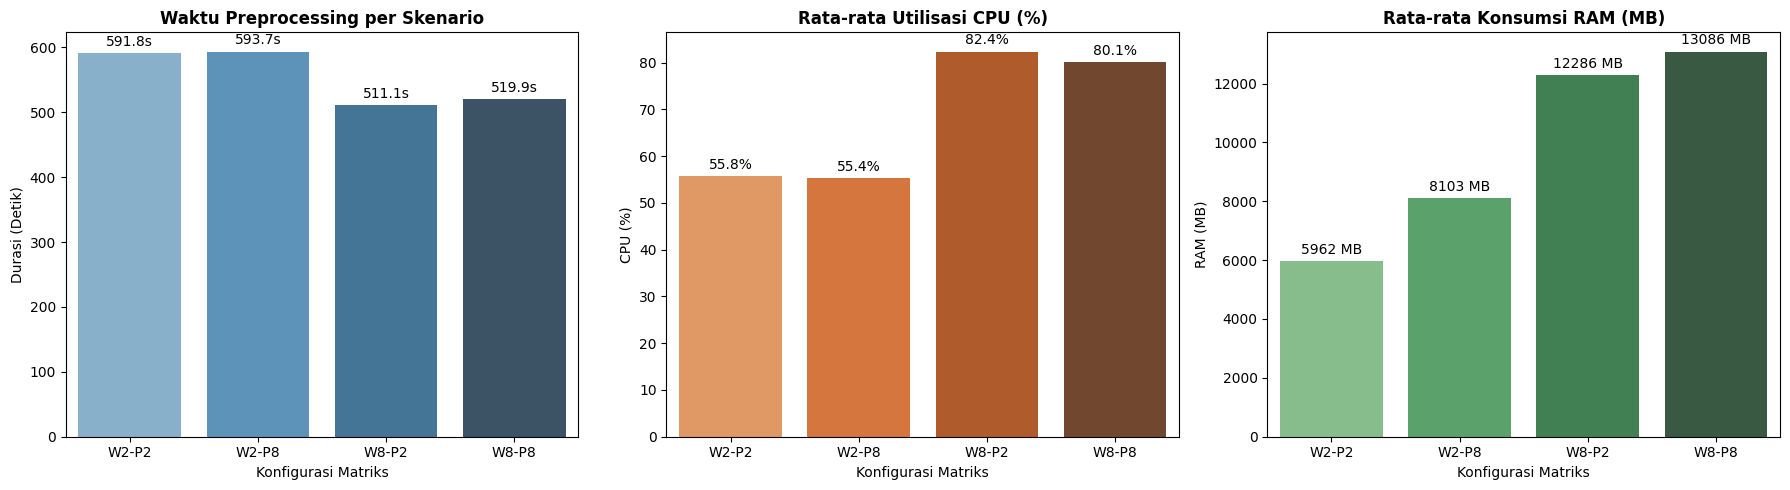

Grafik komparasi berhasil disimpan di: /kaggle/working/riset_kanker_kulit/matriks_komparasi_grafik.png

=== ANALISIS KOMPUTASI TERDISTRIBUSI SKRIPSI ===
1. Konfigurasi preprocessing tercepat saat ini: W8-P2 (511.12 detik).
2. Analisis Efek Partisi (W2-P2 vs W2-P8): Periksa apakah penambahan partisi memecah beban data lebih merata.
3. Analisis Worker Starvation (W8-P2): Dengan 8 worker namun hanya 2 partisi, 6 worker akan menganggur (idle).
4. Analisis Skalabilitas Penuh (W8-P8): Menunjukkan batas konkurensi tertinggi dalam lingkungan virtual Kaggle.


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

if RESULTS_PATH.exists():
    results = pd.read_csv(RESULTS_PATH)
    pre = results[results.stage == 'preprocessing_spark'].drop_duplicates(subset=['scenario_code'], keep='last').sort_values('scenario_code')
    
    if not pre.empty:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Barplot Waktu Preprocessing
        sns.barplot(data=pre, x='scenario_code', y='elapsed_sec', ax=axes[0], palette='Blues_d')
        axes[0].set_title('Waktu Preprocessing per Skenario', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Konfigurasi Matriks')
        axes[0].set_ylabel('Durasi (Detik)')
        for p in axes[0].patches:
            axes[0].annotate(f'{p.get_height():.1f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
        
        # 2. Barplot Utilisasi CPU (%)
        sns.barplot(data=pre, x='scenario_code', y='avg_cpu_percent', ax=axes[1], palette='Oranges_d')
        axes[1].set_title('Rata-rata Utilisasi CPU (%)', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Konfigurasi Matriks')
        axes[1].set_ylabel('CPU (%)')
        for p in axes[1].patches:
            axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
            
        # 3. Barplot Konsumsi RAM (MB)
        sns.barplot(data=pre, x='scenario_code', y='avg_mem_mb', ax=axes[2], palette='Greens_d')
        axes[2].set_title('Rata-rata Konsumsi RAM (MB)', fontsize=12, fontweight='bold')
        axes[2].set_xlabel('Konfigurasi Matriks')
        axes[2].set_ylabel('RAM (MB)')
        for p in axes[2].patches:
            axes[2].annotate(f'{p.get_height():.0f} MB', (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
            
        plt.tight_layout()
        plot_path = PROJECT_DIR / 'matriks_komparasi_grafik.png'
        plt.savefig(plot_path, dpi=300)
        plt.show()
        print(f'Grafik komparasi berhasil disimpan di: {plot_path}')
        
        if len(pre) >= 2:
            fastest = pre.loc[pre.elapsed_sec.idxmin(), 'scenario_code']
            print('\n=== ANALISIS KOMPUTASI TERDISTRIBUSI SKRIPSI ===')
            print(f'1. Konfigurasi preprocessing tercepat saat ini: {fastest} ({pre.elapsed_sec.min():.2f} detik).')
            print('2. Analisis Efek Partisi (W2-P2 vs W2-P8): Periksa apakah penambahan partisi memecah beban data lebih merata.')
            print('3. Analisis Worker Starvation (W8-P2): Dengan 8 worker namun hanya 2 partisi, 6 worker akan menganggur (idle).')
            print('4. Analisis Skalabilitas Penuh (W8-P8): Menunjukkan batas konkurensi tertinggi dalam lingkungan virtual Kaggle.')
        else:
            print('\nCatatan: Jalankan skenario lainnya (W2-P8, W8-P2, W8-P8) untuk melengkapi grafik komparasi Bab 4.')
    else:
        print('Belum ada data preprocessing pada CSV.')


In [61]:
!rm -rf /kaggle/temp/memmap_*


## Fase 10 - Shutdown Daemon & Pembersihan Akhir
Menghentikan seluruh worker dan master Spark Standalone serta layanan HDFS secara teratur setelah eksperimen selesai.


In [ ]:
stop_spark_standalone()
run([str(HADOOP_HOME / 'sbin' / 'stop-dfs.sh')], check=False)
subprocess.run("pkill -f org.apache.spark || true", shell=True)
print('Seluruh layanan Spark Standalone dan HDFS telah dihentikan dengan aman.')
